# 03 — Grafo de conocimiento del dominio para inferencia guiada

**Objetivo:** modelar el dominio inmobiliario de Vivia en un **grafo de conocimiento** y usarlo
para darle al modelo *poco contexto, pero bien limitado*: hechos y ángulos narrativos aprobados
que puede parafrasear para escribir anuncios más "humanizados" **sin inventar**.

**El cambio de estrategia respecto al notebook 02:** los prompts v1/v2 solo *prohibían* inventar,
y aún así el modelo decoraba con "zona residencial" o "buen acceso". Con el grafo invertimos la
lógica: en lugar de una lista negra, el modelo recibe una **lista blanca curada** — la amenidad
"Jardín" *evoca* convivencia familiar y vida al aire libre, con frases semilla aprobadas.
El modelo elige y parafrasea; el negocio controla el universo de lo decible.

**Este notebook trabaja con el draft real de la API transaccional** (JSON anidado con
`propertyType.name`, `address.neighborhoodName`, `availableToRent`, `amenities` con nombre),
no con el testbench CSV sintético de los notebooks anteriores.

**Reglas duras del negocio** (confirmadas):
1. **Nunca mencionar precios ni montos** — el detector de anomalías marcaría el anuncio.
   Por diseño, `listedPrice` ni siquiera entra al contexto del modelo: lo que no ve, no lo menciona.
2. **Nunca lenguaje de contacto/urgencia** ("contáctanos", "llama ya", "agenda tu visita").
   Puramente hablar de la propiedad.
3. **Ubicación = solo el nombre de la colonia.** Sin calle ni números (privacidad),
   sin atributos inventados de la zona.

**Prerrequisito:** haber ejecutado `01_descarga_y_benchmark_qwen3.ipynb`.

## 1. Setup: modelo y drafts de ejemplo

In [1]:
import json
import re
import time
import unicodedata
from datetime import date
from pathlib import Path

import networkx as nx
import pandas as pd
from llama_cpp import Llama

MODEL_PATH = Path("../../models_registry/llm/Qwen3-4B-Instruct-2507-Q4_K_M.gguf").resolve()
assert MODEL_PATH.exists(), "Ejecuta primero 01_descarga_y_benchmark_qwen3.ipynb"

# n_ctx=4096 basta de sobra (prompt ~700 + salida ~400 tokens) y reduce ~0.6 GB de RAM
# frente a 8192. NO usar LlamaRAMCache: guarda una copia completa del estado del modelo
# (>1 GB) por entrada y dispara el consumo de RAM hasta el swap. llama-cpp-python ya
# reutiliza el prefijo común (system prompt) entre llamadas consecutivas sin ningún caché.
llm = Llama(
    model_path=str(MODEL_PATH),
    n_ctx=4096,
    n_threads=4,
    verbose=False,
)

with open("drafts_ejemplo.json") as f:
    DRAFTS = [d["draft"] for d in json.load(f)]

AÑO_ACTUAL = date.today().year
print(f"{len(DRAFTS)} drafts de ejemplo | año actual: {AÑO_ACTUAL}")

7 drafts de ejemplo | año actual: 2026


## 2. Construcción del grafo de dominio

El grafo es la **memoria curada** del redactor. Nodos por tipo:

- **`tema`** — ángulos narrativos con frases semilla aprobadas en español MX (el modelo parafrasea, no copia).
- **`amenidad`** — canónicas, con `aliases` para normalizar lo que llegue en el draft ("GYM" → gimnasio).
- **`tipo_propiedad`** — cómo se narra cada tipo (una casa ≠ un departamento).
- **`operacion`** — tono de renta vs. venta, **sin montos jamás**.
- **`audiencia`** — a quién puede dirigirse el anuncio (se activa por reglas sobre el draft).

Relaciones: `amenidad --evoca--> tema`, `tipo_propiedad --angulo--> tema`, `operacion --evoca--> tema`.

Ampliar el dominio = agregar nodos/aristas aquí, sin tocar prompt ni código de inferencia.

In [2]:
G = nx.DiGraph()

# ── Temas: ángulos narrativos con frases semilla aprobadas ──────────────────
TEMAS = {
    "vida_al_aire_libre": ["espacios para disfrutar el aire libre sin salir de casa",
                            "momentos al exterior en el día a día"],
    "convivencia_familiar": ["pensada para la convivencia en familia",
                              "espacios donde cada quien tiene su lugar"],
    "bienestar": ["facilita una rutina activa y saludable",
                   "bienestar sin salir del hogar"],
    "practicidad": ["resuelve el día a día con comodidad",
                     "una distribución que aprovecha cada metro"],
    "tranquilidad": ["un ritmo de vida tranquilo",
                      "privacidad para descansar"],
    "seguridad": ["acceso controlado para mayor tranquilidad",
                   "un entorno cuidado dentro del condominio"],
    "estilo_moderno": ["diseño actual con personalidad",
                        "ambientes luminosos y contemporáneos"],
    "patrimonio": ["un patrimonio que se disfruta todos los días",
                    "una decisión pensada en el largo plazo"],
    "flexibilidad": ["lista para habitarse sin complicaciones",
                      "ideal para instalarse pronto"],
}
for tema, frases in TEMAS.items():
    G.add_node(f"tema:{tema}", tipo="tema", nombre=tema.replace("_", " "), frases=frases)

# ── Amenidades canónicas: aliases de entrada y temas que evocan ─────────────
AMENIDADES = {
    "terraza":          (["terraza"],                                    ["vida_al_aire_libre"]),
    "jardín":           (["jardin", "jardín", "áreas verdes", "garden"], ["vida_al_aire_libre", "convivencia_familiar"]),
    "gimnasio":         (["gym", "gimnasio", "fitness"],                 ["bienestar"]),
    "alberca":          (["alberca", "piscina", "pool"],                 ["bienestar", "convivencia_familiar"]),
    "roof garden":      (["roof garden", "roofgarden", "roof-garden"],   ["vida_al_aire_libre", "estilo_moderno"]),
    "seguridad":        (["seguridad", "seguridad 24h", "vigilancia", "caseta de vigilancia"], ["seguridad"]),
    "elevador":         (["elevador", "ascensor"],                       ["practicidad"]),
    "patio":            (["patio"],                                      ["vida_al_aire_libre", "convivencia_familiar"]),
    "cuarto de servicio": (["cuarto de servicio"],                       ["practicidad"]),
    "área de lavado":   (["área de lavado", "area de lavado", "cuarto de lavado"], ["practicidad"]),
    "bodega":           (["bodega"],                                     ["practicidad"]),
    "doble altura":     (["doble altura"],                               ["estilo_moderno"]),
    "cocina integral":  (["cocina integral", "cocina equipada"],         ["practicidad"]),
    "balcón":           (["balcon", "balcón"],                           ["vida_al_aire_libre"]),
}
for canonica, (aliases, temas) in AMENIDADES.items():
    nodo = f"amenidad:{canonica}"
    G.add_node(nodo, tipo="amenidad", nombre=canonica, aliases=aliases)
    for t in temas:
        G.add_edge(nodo, f"tema:{t}", relacion="evoca")

# ── Tipos de propiedad: narrativa propia y ángulos ──────────────────────────
TIPOS = {
    "CASA":         ("se narra por sus espacios, su independencia y la vida cotidiana que permite",
                     ["convivencia_familiar", "tranquilidad"]),
    "DEPARTAMENTO": ("se narra por su practicidad, la vida en conjunto y el estilo de vida",
                     ["practicidad", "estilo_moderno"]),
    "LOFT":         ("se narra por su diseño, la amplitud visual y la personalidad del espacio",
                     ["estilo_moderno"]),
    "TERRENO":      ("se narra por su potencial y las posibilidades de proyecto",
                     ["patrimonio"]),
}
for tipo, (narrativa, temas) in TIPOS.items():
    nodo = f"tipo:{tipo}"
    G.add_node(nodo, tipo="tipo_propiedad", nombre=tipo, narrativa=narrativa)
    for t in temas:
        G.add_edge(nodo, f"tema:{t}", relacion="angulo")

# ── Operaciones: tono aprobado, jamás montos ────────────────────────────────
OPERACIONES = {
    "RENTA": ("hogar disponible para renta; enfatiza la vida diaria y la facilidad de instalarse; "
              "jamás menciones montos, rentas ni mensualidades", ["flexibilidad"]),
    "VENTA": ("propiedad en venta; enfatiza permanencia y valor de largo plazo; "
              "jamás menciones precios, montos ni retorno de inversión", ["patrimonio"]),
}
for op, (tono, temas) in OPERACIONES.items():
    nodo = f"operacion:{op}"
    G.add_node(nodo, tipo="operacion", nombre=op, tono=tono)
    for t in temas:
        G.add_edge(nodo, f"tema:{t}", relacion="evoca")

# ── Audiencias: se activan por reglas sobre el draft (sección 4) ────────────
AUDIENCIAS = {
    "familia_grande": "familias que necesitan espacio para todos",
    "familia_pareja": "parejas o familias que van creciendo",
    "profesionista":  "profesionistas que buscan practicidad",
    "persona_sola":   "quien busca un espacio propio y eficiente",
}
for aud, frase in AUDIENCIAS.items():
    G.add_node(f"audiencia:{aud}", tipo="audiencia", nombre=aud.replace("_", " "), frase=frase)

print(f"Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
print({t: sum(1 for _, d in G.nodes(data=True) if d['tipo'] == t)
       for t in ['tema', 'amenidad', 'tipo_propiedad', 'operacion', 'audiencia']})

Grafo: 33 nodos, 26 aristas
{'tema': 9, 'amenidad': 14, 'tipo_propiedad': 4, 'operacion': 2, 'audiencia': 4}


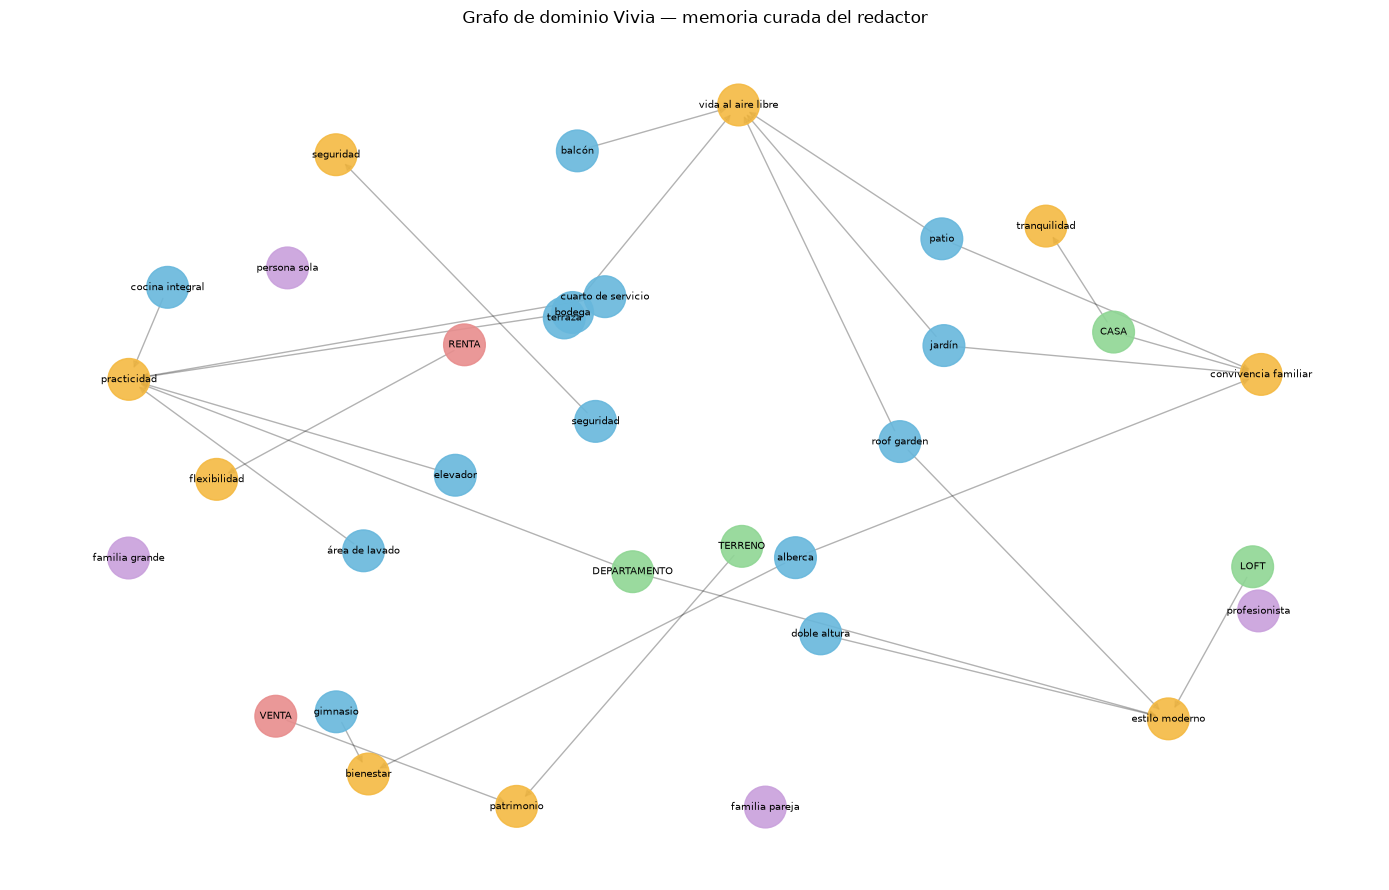

Serializado a grafo_dominio.json


In [3]:
# Visualización rápida + serialización para que después la consuma el servicio.
import matplotlib.pyplot as plt

COLORES = {"tema": "#f4b942", "amenidad": "#67b7dc", "tipo_propiedad": "#8fd694",
           "operacion": "#e88d8d", "audiencia": "#c9a0dc"}

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=0.6)
colores_nodos = [COLORES[G.nodes[n]["tipo"]] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colores_nodos, node_size=900, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True)
nx.draw_networkx_labels(G, pos, {n: G.nodes[n]["nombre"] for n in G.nodes}, font_size=7)
plt.title("Grafo de dominio Vivia — memoria curada del redactor")
plt.axis("off")
plt.tight_layout()
plt.show()

with open("grafo_dominio.json", "w") as f:
    json.dump(nx.node_link_data(G, edges="edges"), f, ensure_ascii=False, indent=2)
print("Serializado a grafo_dominio.json")

## 3. Parser del draft real

Convierte el JSON de la API transaccional en un draft legible. **Exclusiones deliberadas:**

- `listedPrice` — el modelo no debe ver el precio para no poder mencionarlo.
- `street`, `exteriorNumber`, `interiorNumber`, ids — privacidad; solo se usa la colonia.
- `postalCode` — no aporta al anuncio.

In [4]:
def draft_json_a_texto(draft: dict, incluir_precio: bool = False) -> str:
    """Draft de la API → texto para el modelo. `incluir_precio` solo existe para el
    experimento A/B (baseline v2); en producción siempre es False."""
    operacion = "RENTA" if draft["availableToRent"] else "VENTA"
    antiguedad = AÑO_ACTUAL - draft["constructionYear"]
    lineas = [
        f"Tipo de propiedad: {draft['propertyType']['name']}",
        f"Operación: {operacion}",
        f"Colonia: {draft['address']['neighborhoodName']}",
        f"Superficie: {draft['areaM2']:.0f} m²",
        f"Recámaras: {draft['bedrooms']}",
        f"Baños: {draft['bathrooms']}",
    ]
    if draft["parkingSpaces"] > 0:
        lineas.append(f"Estacionamientos: {draft['parkingSpaces']}")
    lineas.append(
        f"Año de construcción: {draft['constructionYear']}"
        + (f" ({antiguedad} años de antigüedad)" if antiguedad > 1 else " (a estrenar)")
    )
    lineas.append(f"En condominio: {'sí' if draft['condominium'] else 'no'}")
    if draft["amenities"]:
        lineas.append(f"Amenidades: {', '.join(draft['amenities'])}")
    if incluir_precio:  # solo para el baseline del A/B
        lineas.append(f"Precio de lista: ${draft['listedPrice']:,.0f} MXN")
    return "\n".join(lineas)


print(draft_json_a_texto(DRAFTS[0]))

Tipo de propiedad: CASA
Operación: RENTA
Colonia: Prudencio Moscoso
Superficie: 200 m²
Recámaras: 4
Baños: 3
Estacionamientos: 2
Año de construcción: 2025 (a estrenar)
En condominio: no
Amenidades: Terraza, Jardín, GYM


## 4. Consulta del grafo: el contexto curado

`contexto_desde_grafo(draft)` recorre el grafo a partir del draft y arma el bloque de
**HECHOS Y ÁNGULOS APROBADOS** (~150–250 tokens):

1. Normaliza cada amenidad por `aliases` ("GYM" → gimnasio). Amenidad desconocida → se lista
   aparte para mencionarse solo por su nombre (fallback seguro).
2. Sigue las aristas `evoca`/`angulo` hacia los temas y toma una frase semilla por tema (sin repetir).
3. Activa audiencias con reglas sobre recámaras/tipo/operación.
4. Agrega hechos derivados (antigüedad, superficie) con redacción aprobada.

In [5]:
def _normalizar(texto: str) -> str:
    texto = unicodedata.normalize("NFKD", texto.lower().strip())
    return "".join(c for c in texto if not unicodedata.combining(c))

ALIAS_A_AMENIDAD = {
    _normalizar(alias): nodo
    for nodo, data in G.nodes(data=True) if data["tipo"] == "amenidad"
    for alias in data["aliases"] + [data["nombre"]]
}


def audiencias_para(draft: dict) -> list[str]:
    tipo = draft["propertyType"]["name"]
    rec, renta = draft["bedrooms"], draft["availableToRent"]
    if rec >= 4 or (rec >= 3 and tipo == "CASA"):
        return ["audiencia:familia_grande"]
    if rec >= 2:
        return ["audiencia:familia_pareja"]
    if renta:
        return ["audiencia:profesionista", "audiencia:persona_sola"]
    return ["audiencia:persona_sola"]


def contexto_desde_grafo(draft: dict) -> str:
    lineas = ["HECHOS Y ÁNGULOS APROBADOS (única fuente permitida además del draft):"]
    temas_usados: set[str] = set()

    # Operación y narrativa del tipo
    op = "RENTA" if draft["availableToRent"] else "VENTA"
    lineas.append(f"- Operación {op}: {G.nodes[f'operacion:{op}']['tono']}.")
    nodo_tipo = f"tipo:{draft['propertyType']['name']}"
    if nodo_tipo in G:
        lineas.append(f"- Un(a) {draft['propertyType']['name'].lower()} {G.nodes[nodo_tipo]['narrativa']}.")
        temas_usados.update(G.successors(nodo_tipo))

    # Amenidades → temas → frases (una frase por tema, sin repetir)
    desconocidas = []
    for amenidad in draft["amenities"]:
        nodo = ALIAS_A_AMENIDAD.get(_normalizar(amenidad))
        if nodo is None:
            desconocidas.append(amenidad)
            continue
        for tema in G.successors(nodo):
            if tema in temas_usados:
                continue
            temas_usados.add(tema)
            frase = G.nodes[tema]["frases"][0]
            lineas.append(f"- {G.nodes[nodo]['nombre']} → {G.nodes[tema]['nombre']}: \"{frase}\".")
    if desconocidas:
        lineas.append(f"- Amenidades sin ángulo aprobado (menciónalas SOLO por su nombre): {', '.join(desconocidas)}.")

    # Audiencias activadas por reglas
    frases_aud = [G.nodes[a]["frase"] for a in audiencias_para(draft)]
    lineas.append(f"- Audiencia sugerida: {'; '.join(frases_aud)}.")

    # Hechos derivados de atributos
    antiguedad = AÑO_ACTUAL - draft["constructionYear"]
    if antiguedad <= 1:
        lineas.append("- Antigüedad: a estrenar — puedes destacar que es de reciente construcción.")
    elif antiguedad <= 10:
        lineas.append("- Antigüedad: construcción reciente.")
    elif antiguedad > 30:
        lineas.append("- Antigüedad: más de 30 años — nómbrala como carácter e historia; "
                      "NO afirmes remodelaciones ni buen estado que el draft no indica.")
    if draft["areaM2"] >= 180:
        lineas.append("- Superficie: puedes describirla como amplia.")
    elif draft["areaM2"] <= 50:
        lineas.append("- Superficie: descríbela como compacta y eficiente, no como amplia.")
    return "\n".join(lineas)


contexto_demo = contexto_desde_grafo(DRAFTS[0])
n_tokens = len(llm.tokenize(contexto_demo.encode("utf-8")))
print(contexto_demo)
print(f"\n→ {n_tokens} tokens de contexto curado")

HECHOS Y ÁNGULOS APROBADOS (única fuente permitida además del draft):
- Operación RENTA: hogar disponible para renta; enfatiza la vida diaria y la facilidad de instalarse; jamás menciones montos, rentas ni mensualidades.
- Un(a) casa se narra por sus espacios, su independencia y la vida cotidiana que permite.
- terraza → vida al aire libre: "espacios para disfrutar el aire libre sin salir de casa".
- gimnasio → bienestar: "facilita una rutina activa y saludable".
- Audiencia sugerida: familias que necesitan espacio para todos.
- Antigüedad: a estrenar — puedes destacar que es de reciente construcción.
- Superficie: puedes describirla como amplia.

→ 184 tokens de contexto curado


## 5. Prompt v3: draft + hechos aprobados

El system prompt es **fijo**: llama.cpp reutiliza automáticamente el prefijo común entre
llamadas consecutivas, así que no se re-procesa completo cada vez. El contexto del grafo viaja
en el mensaje de usuario junto al draft. Nuevas reglas duras: nunca precios, nunca
contacto/urgencia, ubicación solo por colonia.

In [6]:
# Baseline para el A/B: el prompt v2 del notebook 02 (sin grafo, sin reglas de precio/contacto).
SYSTEM_PROMPT_V2 = """Eres un redactor inmobiliario profesional de México. Recibirás el draft de una \
propiedad (sus características estructuradas) y escribirás el anuncio para un portal inmobiliario.

Reglas estrictas:
1. Usa ÚNICAMENTE la información del draft. NO inventes características, ubicaciones, \
amenidades específicas, vistas ni cercanías que no estén en el draft.
2. Escribe en español de México, tono profesional y cálido, dirigido a compradores.
3. El título debe tener máximo 10 palabras y ser atractivo sin ser sensacionalista.
4. La descripción debe tener entre 21 y 70 palabras, en párrafos fluidos (sin listas).
5. No repitas el precio más de una vez. No uses mayúsculas sostenidas ni signos de admiración excesivos.
6. Si el número de amenidades es mayor a cero, menciónalo de forma genérica \
("cuenta con amenidades") sin nombrar amenidades específicas.
7. Usa el vocabulario inmobiliario de la región: di "estacionamientos" (nunca \
"cajones de estacionamiento" ni "plazas de garaje") y "recámaras" (nunca "habitaciones").

Responde exclusivamente con un JSON con las claves "titulo" y "descripcion"."""

SYSTEM_PROMPT_V3 = """Eres un redactor inmobiliario profesional de México. Recibirás el DRAFT de una \
propiedad y un bloque de HECHOS Y ÁNGULOS APROBADOS. Escribirás el anuncio para un portal inmobiliario.

Reglas estrictas:
1. Usa ÚNICAMENTE la información del DRAFT y de los HECHOS Y ÁNGULOS APROBADOS. Puedes \
parafrasear las frases aprobadas con naturalidad, pero NO agregues características, lugares, \
vistas, cercanías ni cualidades que no aparezcan ahí.
2. PROHIBIDO mencionar precios, montos, rentas, mensualidades o cualquier cifra monetaria.
3. PROHIBIDO incluir datos de contacto, invitaciones a llamar, escribir o agendar visitas, \
y lenguaje de urgencia ("aprovecha", "no te lo pierdas", "últimos días").
4. La única ubicación que puedes mencionar es el nombre de la colonia, tal como aparece en el draft.
5. Usa español de México y vocabulario de la región: "recámaras" (nunca "habitaciones") y \
"estacionamientos" (nunca "cajones de estacionamiento" ni "plazas de garaje"). Si el draft no \
menciona estacionamientos, no hables de ellos.
6. El título debe tener máximo 10 palabras, atractivo sin ser sensacionalista.
7. La descripción debe tener entre 21 y 70 palabras, en párrafos fluidos (sin listas), \
con tono cálido y humano, sin mayúsculas sostenidas ni signos de admiración excesivos.

Responde exclusivamente con un JSON con las claves "titulo" y "descripcion"."""

ESQUEMA_ANUNCIO = {
    "type": "object",
    "properties": {"titulo": {"type": "string"}, "descripcion": {"type": "string"}},
    "required": ["titulo", "descripcion"],
}


def generar_anuncio(system_prompt: str, mensaje: str, temperature: float = 1.0,
                    max_tokens: int = 512) -> dict:
    t0 = time.perf_counter()
    salida = llm.create_chat_completion(
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": mensaje},
        ],
        response_format={"type": "json_object", "schema": ESQUEMA_ANUNCIO},
        temperature=temperature,
        max_tokens=max_tokens,
    )
    anuncio = json.loads(salida["choices"][0]["message"]["content"])
    anuncio["tiempo_s"] = round(time.perf_counter() - t0, 1)
    anuncio["tokens_prompt"] = salida["usage"]["prompt_tokens"]
    return anuncio


def generar_v2(draft: dict, **kw) -> dict:
    # Baseline: como el notebook 02 — draft plano CON precio y sin grafo.
    return generar_anuncio(SYSTEM_PROMPT_V2,
                           f"Draft de la propiedad:\n{draft_json_a_texto(draft, incluir_precio=True)}", **kw)


def generar_v3(draft: dict, **kw) -> dict:
    mensaje = (f"DRAFT DE LA PROPIEDAD:\n{draft_json_a_texto(draft)}\n\n"
               f"{contexto_desde_grafo(draft)}")
    return generar_anuncio(SYSTEM_PROMPT_V3, mensaje, **kw)


# Demo con el draft real del ejemplo (casa en Prudencio Moscoso)
demo = generar_v3(DRAFTS[0])
print(f"⏱ {demo['tiempo_s']} s | prompt: {demo['tokens_prompt']} tokens\n")
print(f"TÍTULO: {demo['titulo']}\n\n{demo['descripcion']}")

⏱ 39.3 s | prompt: 699 tokens

TÍTULO: Casa de reciente construcción en Prudencio Moscoso

Una casa amplia y moderna en la colonia Prudencio Moscoso, lista para recibir a familiares y amigos. Con cuatro recámaras y tres baños, ofrece espacio para la vida diaria. La terraza permite disfrutar el aire libre sin salir de casa, mientras el gimnasio facilita una rutina activa y saludable. A estrenar, con acabados nuevos y un diseño que prioriza comodidad y bienestar.


## 6. A/B: v2 (sin grafo) vs v3 (con grafo)

Los mismos 7 drafts con ambas variantes. Además de la revisión manual, se verifica
**programáticamente** que v3 nunca mencione precios ni lenguaje de contacto/urgencia.

Notas:
- Se corren todas las v2 primero y luego todas las v3: el prefijo común (system prompt) se
  reutiliza entre llamadas consecutivas y alternar variantes lo invalidaría en cada paso.
- Antes de correr, apaga los kernels de los notebooks 01/02 (cada uno retiene su propia copia
  del modelo, ~4–5 GB de RAM).

In [7]:
RE_PRECIO = re.compile(r"\$|\bprecio\b|\bmxn\b|\bpesos?\b|mensualidad|mill[oó]n|\bmonto\b", re.I)
RE_CONTACTO = re.compile(
    r"cont[aá]ct|ll[aá]m[ae]|tel[eé]fono|whatsapp|escr[ií]b[ae]|agend[ae]|vis[ií]t[ae]|"
    r"aprovecha|no te lo pierdas|[uú]ltimos d[ií]as|cita", re.I)


def verificar(anuncio: dict) -> dict:
    texto = f"{anuncio['titulo']} {anuncio['descripcion']}"
    return {
        "menciona_precio": bool(RE_PRECIO.search(texto)),
        "menciona_contacto": bool(RE_CONTACTO.search(texto)),
        "n_palabras": len(anuncio["descripcion"].split()),
    }


filas = []
for variante, generar in (("v2", generar_v2), ("v3", generar_v3)):
    for draft in DRAFTS:
        anuncio = generar(draft)
        checks = verificar(anuncio)
        filas.append({"draft_id": draft["id"], "variante": variante,
                      "titulo": anuncio["titulo"], "descripcion": anuncio["descripcion"],
                      "tokens_prompt": anuncio["tokens_prompt"], "tiempo_s": anuncio["tiempo_s"],
                      **checks})
        marca = "⚠️" if checks["menciona_precio"] or checks["menciona_contacto"] else "✓"
        print(f"{marca} [{variante}] {draft['id']}: {anuncio['titulo']} "
              f"({anuncio['tiempo_s']} s, prompt {anuncio['tokens_prompt']} tok)")

df_ab = pd.DataFrame(filas)
df_ab.to_csv("resultados_ab_grafo.csv", index=False)

print("\n--- Resumen por variante ---")
display(df_ab.groupby("variante")[["menciona_precio", "menciona_contacto", "tokens_prompt",
                                     "tiempo_s", "n_palabras"]].agg(
    {"menciona_precio": "sum", "menciona_contacto": "sum", "tokens_prompt": "mean",
     "tiempo_s": "mean", "n_palabras": "mean"}).round(1))

✓ [v2] draft-001: Casa a estrenar en Prudencio Moscoso (31.2 s, prompt 431 tok)
✓ [v2] draft-002: Departamento en El Cerrillo con Alberca y Seguridad 24h (21.5 s, prompt 436 tok)
✓ [v2] draft-003: Casa de 5 recámaras en Barrio de Guadalupe (21.1 s, prompt 431 tok)
✓ [v2] draft-004: Departamento en La Isla con vista al roof garden (17.1 s, prompt 417 tok)
✓ [v2] draft-005: Casa en 31 de Marzo, 3 recámaras (19.4 s, prompt 416 tok)
✓ [v2] draft-006: Departamento en Real del Monte con 3 Recámaras (20.4 s, prompt 431 tok)
✓ [v2] draft-007: Loft en Centro con doble altura (19.9 s, prompt 414 tok)
✓ [v3] draft-001: Casa de reciente construcción en Prudencio Moscoso (35.7 s, prompt 699 tok)
✓ [v3] draft-002: Departamento en El Cerrillo con alberca y seguridad (26.1 s, prompt 677 tok)
✓ [v3] draft-003: Casa amplia en Barrio de Guadalupe (28.0 s, prompt 707 tok)
✓ [v3] draft-004: Departamento práctico en La Isla (24.5 s, prompt 673 tok)
✓ [v3] draft-005: Casa de 3 recámaras en 31 de Marzo (22.7 

,menciona_precio,menciona_contacto,tokens_prompt,tiempo_s,n_palabras
variante,,,,,
v2,0,0,425.1,21.5,52.6
v3,0,0,669.6,26.1,59.7


In [ ]:
# Lectura lado a lado de un draft para evaluar la "humanización" (el criterio manual).
for _, fila in df_ab[df_ab["draft_id"] == "draft-001"].iterrows():
    print(f"{'=' * 70}\n### {fila['variante']} — {fila['titulo']}\n")
    print(fila["descripcion"], "\n")

### v2 — Casa a estrenar en Prudencio Moscoso

Linda casa de 200 m² a estrenar en la colonia Prudencio Moscoso, construida en 2025. Cuenta con 4 recámaras, 3 baños, estacionamientos para dos vehículos y espacios al aire libre como terraza y jardín. Disfruta de una vivienda moderna con acceso a un gimnasio. Ideal para quien busca comodidad y diseño actual en un entorno familiar. 

### v3 — Casa de reciente construcción en Prudencio Moscoso

Una casa amplia y moderna, a estrenar, en el corazón de Prudencio Moscoso. Ofrece espacio para vivir con tranquilidad y bienestar. Cuenta con terraza para disfrutar el aire libre sin salir de casa y un gimnasio para mantener una rutina activa y saludable. Ideal para familias que buscan un hogar con independencia y espacios para todos. 



: 

## 7. Evaluación y bitácora

Revisar `resultados_ab_grafo.csv` y marcar:

- [ ] **Sin precio:** 0 menciones de precio/montos en v3 (verificación automática arriba)
- [ ] **Sin contacto/urgencia:** 0 menciones en v3 (verificación automática arriba)
- [ ] **Fidelidad:** v3 solo usa hechos del draft + ángulos del grafo (revisar contra el contexto curado)
- [ ] **Ubicación:** solo el nombre de la colonia, nunca calle/números ni atributos de la zona
- [ ] **Humanización:** ¿v3 se lee más natural y con más "ángulo" que v2? (comparación lado a lado)
- [ ] **Costo:** tokens de prompt de v3 vs v2 y efecto en tiempo por anuncio

### Bitácora de versiones

| Versión | Cambio | Resultado |
|---|---|---|
| v1 | Prompt inicial con regla anti-invención | Invención leve de entorno; "cajones de estacionamiento" copiado del draft |
| v2 | Vocabulario regional; temperature 1.0 | |
| v3 | Grafo de dominio: contexto curado (whitelist) + reglas duras sin precio / sin contacto / solo colonia; draft real de la API | |

**Cómo crece el grafo:** agregar amenidades/temas/frases en la sección 2 (es la única fuente).
En producción, `grafo_dominio.json` será un artefacto versionado (candidato a MLflow) que el
worker cargará junto al GGUF.

**Siguientes pasos** (fuera de este notebook): benchmark en el VPS, contenedor `llama-server` +
worker de `llm_queue` que reciba el draft JSON, consulte el grafo y genere con el prompt v3.